# Test grafico di `metricEuclidean`
- $V_0 < 0$: collision
- $V_0 > 0$: no collision
- $V_0 = 0$: contact

In [1]:
from pathlib import Path
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# Permette di eseguire il notebook sia dalla radice del progetto sia da tests/.
project_root = Path.cwd()
if not (project_root / "hj_reachability").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from hj_reachability import Grid, sets
from hj_reachability.vehicle.geometry import build_terminal_set_boundary
from hj_reachability.vehicle.metrics import metricEuclidean

## 1. 6D grid

$$z = [x_{rel}, y_{rel}, \theta_{rel}, v_H, \delta_E, v_E].$$

In [2]:
grid = Grid.from_lattice_parameters_and_boundary_conditions(
    domain=sets.Box(
        lo=jnp.array([-8.0, -6.0, -0.5 * np.pi, 0.0, -0.10, 0.0]),
        hi=jnp.array([ 8.0,  6.0,  0.5 * np.pi, 20.0, 0.10, 20.0]),
    ),
    shape=(41, 31, 10, 2, 2, 2),
    periodic_dims=2,
)

print("Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]")
print("Forma della griglia:", grid.shape)
print("Numero totale di stati:", int(np.prod(grid.shape)))

Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]
Forma della griglia: (41, 31, 10, 2, 2, 2)
Numero totale di stati: 101680


## 2. Terminal set boundary and metric evaluation

In [3]:
boundary = build_terminal_set_boundary(
    n_theta=90,
    n_phi=180,
)

result = metricEuclidean(
    grid=grid,
    boundary=boundary,
)

V0 = np.asarray(result.terminal_values)

print("Forma di V0:", V0.shape)
print(f"Intervallo di V0: [{V0.min():.3f}, {V0.max():.3f}]")
print(f"Scala angolare s_theta: {result.angular_scale:.3f} m/rad")
print("Tutti i punti sono validi:", bool(np.asarray(result.valid).all()))

Forma di V0: (41, 31, 10, 2, 2, 2)
Intervallo di V0: [-3.388, 5.852]
Scala angolare s_theta: 3.183 m/rad
Tutti i punti sono validi: True


## 3. Slice scatter plot

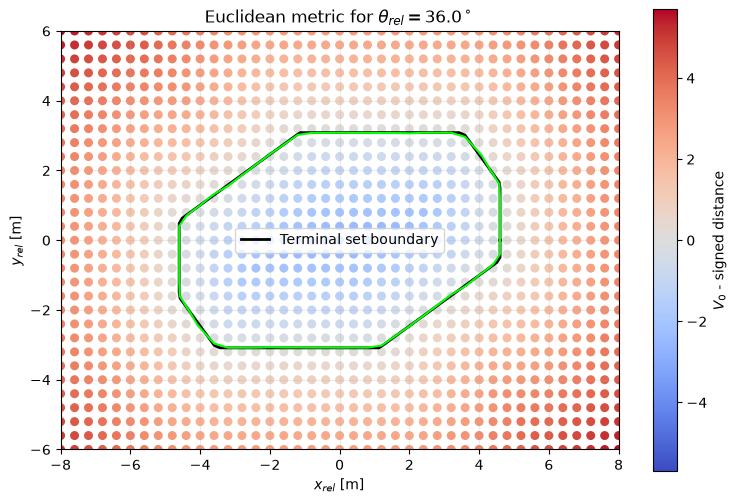

In [ ]:
x_axis = np.asarray(grid.coordinate_vectors[0])
y_axis = np.asarray(grid.coordinate_vectors[1])
theta_axis = np.asarray(grid.coordinate_vectors[2])

theta_target = np.deg2rad(30)
i_theta = int(np.argmin(np.abs(theta_axis - theta_target)))
theta_plot = float(theta_axis[i_theta])
V0_slice = V0[:, :, i_theta, 0, 0, 0]
x_plot, y_plot = np.meshgrid(x_axis, y_axis, indexing="ij")

i_boundary = int(np.argmin(np.abs(boundary.theta - theta_plot)))
B_slice = boundary.points[i_boundary]
B_closed = np.vstack((B_slice, B_slice[0]))

value_limit = float(np.max(np.abs(V0_slice)))
norm = TwoSlopeNorm(vmin=-value_limit, vcenter=0.0, vmax=value_limit)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    x_plot.ravel(),
    y_plot.ravel(),
    c=V0_slice.ravel(),
    cmap="coolwarm",
    norm=norm,
    s=42,
    edgecolors="none",
)
ax.plot(B_closed[:, 0], B_closed[:, 1], "k-", linewidth=2.0, label="Terminal set boundary")
ax.contour(x_plot, y_plot, V0_slice, levels=[0.0], colors="lime", linewidths=1.5)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(r"$V_0$ - signed distance")
ax.set_xlabel(r"$x_{rel}$ [m]")
ax.set_ylabel(r"$y_{rel}$ [m]")
ax.set_title(rf"Euclidean metric for $\theta_{{rel}}={np.rad2deg(theta_plot):.1f}^\circ$")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()